# 1. Instalasi Library

---



In [11]:
!pip install pytorch-forecasting pytorch-lightning -q

# 2. Setup & Load Data

---



In [12]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

BASE_PATH = '/content/drive/MyDrive/stock_prediction-lstm-tft'
CLEAN_PATH = f'{BASE_PATH}/02_data/clean'
COLAB_PATH = f'{BASE_PATH}/03_colab'
TFT_PATH   = f'{BASE_PATH}/04_model/tft'
RESULTS_PATH = f'{BASE_PATH}/05_results/tft/figures'

os.makedirs(TFT_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

# Load data scaled
df = pd.read_csv(f'{CLEAN_PATH}/lq45_scaled.csv')
df['price_date'] = pd.to_datetime(df['price_date'])
df = df.sort_values(by=['symbol', 'price_date']).reset_index(drop=True)
print("Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (7090, 12)


,id,symbol,company_name,open_price,high_price,low_price,close_price,volume,price_date,MA7,MA30,RSI
0,2924,ASII.JK,Astra International,0.414058,0.376342,0.403136,0.403023,0.138231,2020-02-12,0.419954,0.497745,0.140010
1,2925,ASII.JK,Astra International,0.399555,0.365007,0.403136,0.399286,0.078378,2020-02-13,0.409551,0.492557,0.146375
2,2926,ASII.JK,Astra International,0.399555,0.376342,0.403136,0.421716,0.170676,2020-02-14,0.402615,0.487790,0.268029
3,2927,ASII.JK,Astra International,0.424937,0.387677,0.421766,0.421716,0.023904,2020-02-17,0.393368,0.484144,0.214471
4,2928,ASII.JK,Astra International,0.410434,0.391456,0.421766,0.421716,0.061621,2020-02-18,0.386432,0.480358,0.214471


# 3. Persiapan Data untuk TFT
TFT memerlukan format data yang berbeda dari LSTM. Data harus memiliki
time index berupa integer dan group identifier berupa string.

---



In [13]:
# Tambah time index integer per saham
df['time_idx'] = df.groupby('symbol').cumcount()

# Pastikan symbol bertipe string
df['symbol'] = df['symbol'].astype(str)

# Definisi kolom
target = 'close_price'
group_col = 'symbol'
time_col = 'time_idx'

feature_cols = ['open_price', 'high_price', 'low_price', 'volume', 'MA7', 'MA30', 'RSI']

LOOKBACK = 30
PREDICTION_LENGTH = 1

# Tentukan max time idx per saham
max_time_idx = df.groupby('symbol')['time_idx'].max().min()

# Split 70% train, 15% val, 15% test
train_cutoff = int(max_time_idx * 0.70)
val_cutoff   = int(max_time_idx * 0.85)

print("Max time idx:", max_time_idx)
print("Train cutoff:", train_cutoff)
print("Val cutoff  :", val_cutoff)

Max time idx: 1417
Train cutoff: 991
Val cutoff  : 1204


# 4. Membuat TimeSeriesDataSet

---



In [15]:
training = TimeSeriesDataSet(
    df[df['time_idx'] <= train_cutoff],
    time_idx=time_col,
    target=target,
    group_ids=[group_col],
    min_encoder_length=LOOKBACK // 2,
    max_encoder_length=LOOKBACK,
    min_prediction_length=PREDICTION_LENGTH,
    max_prediction_length=PREDICTION_LENGTH,
    time_varying_known_reals=[time_col],
    time_varying_unknown_reals=feature_cols + [target],
    target_normalizer=GroupNormalizer(groups=[group_col]),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df[(df['time_idx'] > train_cutoff) & (df['time_idx'] <= val_cutoff)],
    stop_randomization=True
)

train_dataloader = training.to_dataloader(train=True, batch_size=32, num_workers=0)
val_dataloader   = validation.to_dataloader(train=False, batch_size=32, num_workers=0)

print("Training dataset size:", len(training))
print("Validation dataset size:", len(validation))

Training dataset size: 4960
Validation dataset size: 1065


# 5. Arsitektur Model TFT

---



In [16]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=MAE(),
    optimizer='adam',
    log_interval=10,
    reduce_on_plateau_patience=4,
)

print(f"Parameter count: {tft.size()/1e3:.1f}k")

Parameter count: 83.3k


## 6. Pelatihan Model TFT

---



In [17]:
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')

checkpoint = ModelCheckpoint(
    dirpath=TFT_PATH,
    filename='tft_best',
    monitor='val_loss',
    save_top_k=1,
    mode='min'
)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator='auto',
    gradient_clip_val=0.1,
    callbacks=[early_stop, checkpoint],
    enable_progress_bar=True,
    logger=TensorBoardLogger(f'{TFT_PATH}/logs')
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

print("Training selesai!")
print(f"Best model: {checkpoint.best_model_path}")

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MAE                             │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    416 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 20.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     33 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 83.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 83.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 380                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Training selesai!
Best model: /content/drive/MyDrive/stock_prediction-lstm-tft/04_model/tft/tft_best.ckpt


## 7. Prediksi & Evaluasi

---



In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load best model
best_model = TemporalFusionTransformer.load_from_checkpoint(checkpoint.best_model_path)
best_model.eval()

# Prediksi
predictions = best_model.predict(val_dataloader, return_y=True)
y_pred = predictions.output.numpy().flatten()
y_test = predictions.y[0].numpy().flatten()

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mape_val = mape(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape_val:.2f}%")
print(f"R²   : {r2:.4f}")

# Simpan hasil
tft_results = {
    'y_test': y_test, 'y_pred': y_pred,
    'RMSE': rmse, 'MAE': mae, 'MAPE': mape_val, 'R2': r2
}

with open(f'{TFT_PATH}/tft_results.pkl', 'wb') as f:
    pickle.dump(tft_results, f)

print("Hasil evaluasi tersimpan!")

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

RMSE : 0.0448
MAE  : 0.0305
MAPE : 7.45%
R²   : 0.9695
Hasil evaluasi tersimpan!


## 8. Visualisasi Prediksi vs Aktual

---



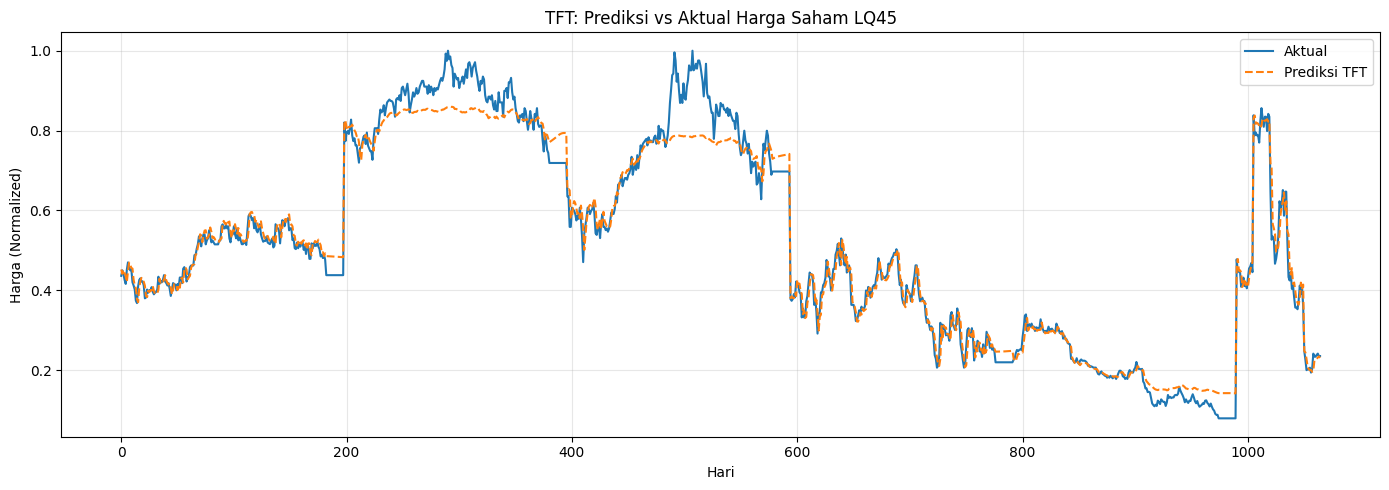

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Aktual', linewidth=1.5)
plt.plot(y_pred, label='Prediksi TFT', linewidth=1.5, linestyle='--')
plt.title('TFT: Prediksi vs Aktual Harga Saham LQ45')
plt.xlabel('Hari')
plt.ylabel('Harga (Normalized)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/tft_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Visualisasi Attention
Visualisasi attention weight untuk melihat fitur mana yang paling
berpengaruh dalam prediksi TFT.

---



INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

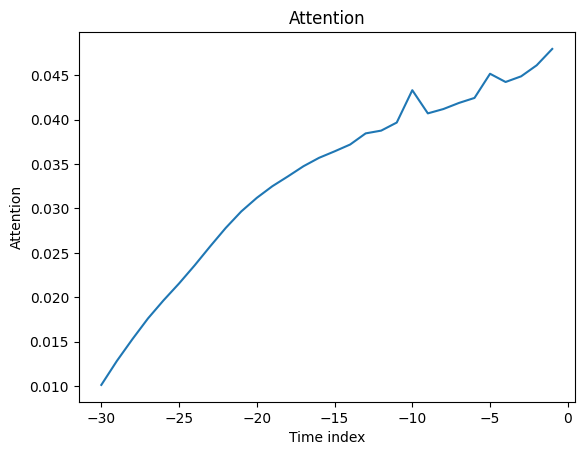

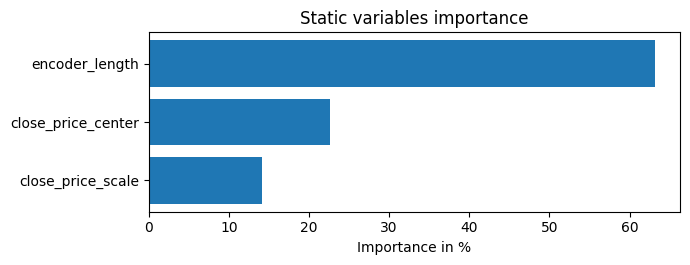

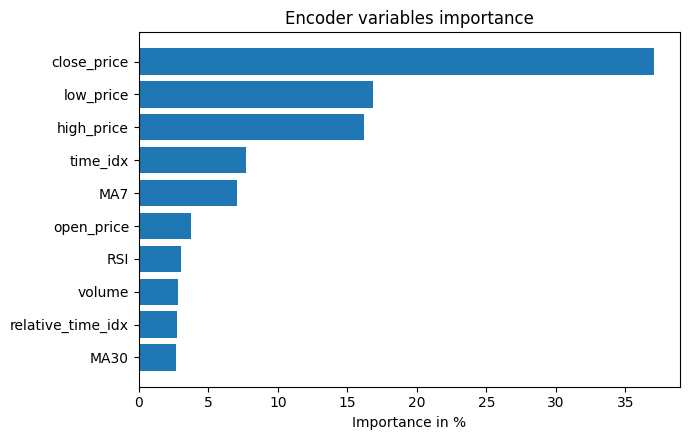

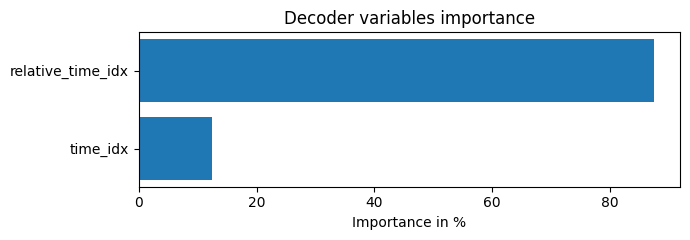

In [20]:
interpretation = best_model.interpret_output(
    best_model.predict(val_dataloader, mode='raw', return_x=True).output,
    reduction='sum'
)

best_model.plot_interpretation(interpretation)
plt.savefig(f'{RESULTS_PATH}/tft_attention.png', dpi=150, bbox_inches='tight')
plt.show()